# Bayesian Parameter Uncertainty

Summary notebook for Bayesian posterior sample CSV files under `bayesian parameters/`.
It maps either named parameter columns or `param_i` columns back to the active
card parameter names, reports central 68% posterior intervals, and summarizes
parameter correlations for the stored posterior samples.


In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [2]:
fit_name = "Final_old"
sample_results_path = Path("bayesian parameters/bayesian_parameters.csv")
pairplot_mode = "free"  # "free" or "all"
use_success_only = False
show_success_failure_overlay = False
export_correlation_pdf = True
correlation_plot_pdf_path = Path("Plots/parameter_correlation_bayesian.pdf")
central_summary_mode = "mean"  # "median" or "mean"


In [3]:
card_path = Path("../Cards") / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)

def latex_param_name(name):
    special = {
        "logx0": r"$\log x_0$",
        "sigx": r"$\sigma_x$",
        "amp": r"$A_{\rm NP}$",
        "BNP": r"$B_{\rm NP}$",
    }
    if name in special:
        return special[name]

    match = re.fullmatch(r"([A-Za-z]+)(\d+)", name)
    if match:
        base, idx = match.groups()
        if base == "lambda":
            return rf"$\lambda_{{{idx}}}$"
        return rf"${base}_{{{idx}}}$"

    return rf"${name}$"

latex_param_labels = {name: latex_param_name(name) for name in param_names}
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "latex_label": [latex_param_labels[name] for name in param_names],
        "initial_value": initial_params[: len(param_names)],
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,latex_label,initial_value,frozen
0,0,lambda1,$\lambda_{1}$,0.023656,False
1,1,lambda2,$\lambda_{2}$,1.054291,False
2,2,lambda3,$\lambda_{3}$,-2.354365,False
3,3,logx0,$\log x_0$,-5.207703,False
4,4,sigx,$\sigma_x$,1.103274,False
5,5,amp,$A_{\rm NP}$,-0.431106,False
6,6,BNP,$B_{\rm NP}$,1.494665,False
7,7,c0,$c_{0}$,0.070013,False
8,8,c1,$c_{1}$,0.027637,False


In [4]:
def load_parameter_samples(path):
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{path} does not contain any parameter samples")

    working = df.copy()

    if all(col in working.columns for col in param_columns):
        for col in param_columns:
            working[col] = pd.to_numeric(working[col], errors="coerce")
        for col, name in zip(param_columns, param_names):
            working[name] = working[col]
    elif all(name in working.columns for name in param_names):
        for name in param_names:
            working[name] = pd.to_numeric(working[name], errors="coerce")
        for col, name in zip(param_columns, param_names):
            working[col] = working[name]
    else:
        raise ValueError(
            f"{path} must contain either {param_columns} or the named parameter columns {param_names}"
        )

    has_explicit_success = "success" in working.columns

    if "replica_id" not in working.columns:
        if "source_index" in working.columns:
            working["replica_id"] = pd.to_numeric(working["source_index"], errors="coerce")
        else:
            working["replica_id"] = np.arange(len(working), dtype=int)
    if "success" not in working.columns:
        working["success"] = 1
    if "nfev" not in working.columns:
        working["nfev"] = pd.Series(pd.array([pd.NA] * len(working), dtype="Int64"), index=working.index)
    else:
        working["nfev"] = pd.to_numeric(working["nfev"], errors="coerce").astype("Int64")
    if "best_chi2dN" not in working.columns:
        working["best_chi2dN"] = np.nan
    else:
        working["best_chi2dN"] = pd.to_numeric(working["best_chi2dN"], errors="coerce")

    if "source_index" not in working.columns:
        working["source_index"] = pd.Series(pd.array([pd.NA] * len(working), dtype="Int64"), index=working.index)
    else:
        working["source_index"] = pd.to_numeric(working["source_index"], errors="coerce").astype("Int64")

    if "log_prob" not in working.columns:
        working["log_prob"] = np.nan
    else:
        working["log_prob"] = pd.to_numeric(working["log_prob"], errors="coerce")

    if "pdf_replica_id" not in working.columns:
        working["pdf_replica_id"] = pd.Series(pd.array([pd.NA] * len(working), dtype="string"), index=working.index)
    else:
        working["pdf_replica_id"] = working["pdf_replica_id"].astype("string")

    if "pdf_shift_seed" not in working.columns:
        working["pdf_shift_seed"] = pd.Series(pd.array([pd.NA] * len(working), dtype="Int64"), index=working.index)
    else:
        working["pdf_shift_seed"] = pd.to_numeric(working["pdf_shift_seed"], errors="coerce").astype("Int64")

    numeric_columns = ["replica_id", "success", *param_columns]
    for col in numeric_columns:
        working[col] = pd.to_numeric(working[col], errors="coerce")

    required_columns = ["replica_id", *param_columns]
    working = working.dropna(subset=required_columns).copy()
    working["replica_id"] = working["replica_id"].astype(int)
    working["success"] = pd.to_numeric(working["success"], errors="coerce").astype("Int64")

    if has_explicit_success:
        bad_success_values = sorted(set(working["success"].dropna().astype(int)) - {0, 1})
        if bad_success_values:
            raise ValueError(
                f"Parsed success column contains non-binary values {bad_success_values}; CSV schema may be misaligned"
            )

    return working.sort_values("replica_id").reset_index(drop=True), has_explicit_success

parameter_results_all_df, has_explicit_success = load_parameter_samples(sample_results_path)
parameter_results_df = parameter_results_all_df.copy()
effective_use_success_only = bool(use_success_only and has_explicit_success)
if effective_use_success_only:
    parameter_results_df = parameter_results_df[parameter_results_df["success"] == 1].reset_index(drop=True)

print(f"Loaded {len(parameter_results_df)} parameter samples from {sample_results_path}")
print(f"central_summary_mode = {central_summary_mode}")
if has_explicit_success:
    print(f"use_success_only = {effective_use_success_only}")
    print("success counts in source file:")
    display(parameter_results_all_df["success"].value_counts(dropna=False).sort_index().rename("count").to_frame())
else:
    print("No explicit success column in source file; all rows are treated as posterior samples.")

duplicate_counts = parameter_results_all_df["replica_id"].value_counts()
duplicate_ids = duplicate_counts[duplicate_counts > 1]
if not duplicate_ids.empty:
    print("warning: duplicate replica_id values found in source file")
    display(duplicate_ids.rename("count").to_frame())

preview_cols = [
    "replica_id",
    "source_index",
    "log_prob",
    "success",
    "nfev",
    "best_chi2dN",
    "pdf_replica_id",
    "pdf_shift_seed",
]
preview_cols.extend(param_names)
display(parameter_results_df[preview_cols].head())


Loaded 1000 parameter samples from bayesian parameters\bayesian_parameters.csv
central_summary_mode = mean
No explicit success column in source file; all rows are treated as posterior samples.


,replica_id,source_index,log_prob,success,nfev,best_chi2dN,pdf_replica_id,pdf_shift_seed,lambda1,lambda2,lambda3,logx0,sigx,amp,BNP,c0,c1
0,9,9,-186.607928,1,<NA>,NaN,<NA>,<NA>,0.004001,1.066987,-2.639572,-5.354135,1.032392,-0.464033,1.915794,0.059724,0.022447
1,41,41,-184.315792,1,<NA>,NaN,<NA>,<NA>,0.002548,1.122492,-2.657517,-5.301107,1.660783,-0.429345,1.741697,0.064500,0.026654
2,51,51,-185.509553,1,<NA>,NaN,<NA>,<NA>,-0.008229,1.084817,-2.818570,-5.745763,1.447606,-0.570028,1.801397,0.065770,0.027093
3,76,76,-188.391945,1,<NA>,NaN,<NA>,<NA>,0.072423,1.479139,-3.174244,-5.034232,1.974748,-0.435425,1.671421,0.067712,0.027458
4,85,85,-184.582612,1,<NA>,NaN,<NA>,<NA>,0.000150,1.076239,-2.828981,-5.411874,1.594033,-0.441847,1.937314,0.064434,0.022292


In [5]:
alpha = 0.15865

def summarize_columns(df, columns):
    summary = pd.DataFrame(index=columns)
    summary["mean"] = df[columns].mean()
    summary["std"] = df[columns].std(ddof=1)
    summary["q_lo"] = df[columns].quantile(alpha)
    summary["median"] = df[columns].quantile(0.5)
    summary["q_hi"] = df[columns].quantile(1.0 - alpha)
    summary["central"] = np.nan
    summary["minus"] = np.nan
    summary["plus"] = np.nan
    return summary

def format_sig(value, sig):
    from decimal import Decimal

    value = float(value)
    if np.isnan(value):
        return "nan"
    if value == 0:
        return "0." + "0" * (sig - 1)

    decimal_value = Decimal(str(value))
    exponent = abs(decimal_value).adjusted()
    places = sig - exponent - 1
    rounded = decimal_value.quantize(Decimal(f"1e{-places}"))
    rounded_exponent = abs(rounded).adjusted()
    places = sig - rounded_exponent - 1
    rounded = decimal_value.quantize(Decimal(f"1e{-places}"))

    if places > 0:
        return format(rounded, f".{places}f")
    if places == 0:
        return format(rounded, ".0f")
    return format(rounded, "f")

param_summary = summarize_columns(parameter_results_df, param_columns)
param_summary.insert(0, "parameter", param_names)
param_summary.insert(1, "initial_value", initial_params[: len(param_names)])
param_summary.insert(2, "frozen", [i in frozen_set for i in range(len(param_names))])

if central_summary_mode == "median":
    param_summary["central"] = param_summary["median"]
elif central_summary_mode == "mean":
    param_summary["central"] = param_summary["mean"]
else:
    raise ValueError(f"Unknown central_summary_mode={central_summary_mode!r}")

param_summary["minus"] = param_summary["central"] - param_summary["q_lo"]
param_summary["plus"] = param_summary["q_hi"] - param_summary["central"]
display(param_summary)

paper_param_summary = param_summary.set_index("parameter", drop=False).copy()
logx0_row = paper_param_summary.loc["logx0"]
x0_initial = np.exp(logx0_row["initial_value"])
x0_mean = np.exp(logx0_row["mean"])
x0_q_lo = np.exp(logx0_row["q_lo"])
x0_median = np.exp(logx0_row["median"])
x0_q_hi = np.exp(logx0_row["q_hi"])
x0_central = np.exp(logx0_row["central"])
x0_minus = x0_central - x0_q_lo
x0_plus = x0_q_hi - x0_central
paper_param_summary.loc["x0"] = {
    "parameter": "x0",
    "initial_value": x0_initial,
    "frozen": bool(logx0_row["frozen"]),
    "mean": x0_mean,
    "std": np.nan,
    "q_lo": x0_q_lo,
    "median": x0_median,
    "q_hi": x0_q_hi,
    "central": x0_central,
    "minus": x0_minus,
    "plus": x0_plus,
}

paper_order = ["lambda1", "lambda2", "lambda3", "x0", "sigx", "amp", "BNP", "c0", "c1"]
paper_labels = {
    "c0": r"$c_0$",
    "c1": r"$c_1$",
    "BNP": r"$B_{\mathrm{NP}}$",
    "lambda1": r"$\lambda_1$",
    "lambda2": r"$\lambda_2$",
    "lambda3": r"$\lambda_3$",
    "amp": r"$A_{\mathrm{NP}}$",
    "x0": r"$x_0$",
    "sigx": r"$\sigma_x$",
}
paper_param_summary = paper_param_summary.loc[paper_order].copy()
paper_param_summary["latex_label"] = [paper_labels[name] for name in paper_param_summary["parameter"]]
minus_glyph = "\N{MINUS SIGN}"
paper_param_summary["display_central"] = paper_param_summary["central"].map(lambda value: format_sig(value, 3))
paper_param_summary["display_minus"] = paper_param_summary["minus"].map(lambda value: format_sig(value, 2))
paper_param_summary["display_plus"] = paper_param_summary["plus"].map(lambda value: format_sig(value, 2))
paper_param_summary["display_entry"] = paper_param_summary.apply(
    lambda row: f"{row['display_central']}^(+{row['display_plus']})_({minus_glyph}{row['display_minus']})",
    axis=1,
)
paper_param_summary["latex_entry"] = paper_param_summary.apply(
    lambda row: rf"{row['display_central']}^{{+{row['display_plus']}}}_{{-{row['display_minus']}}}",
    axis=1,
)
display(paper_param_summary[["latex_label", "display_central", "display_minus", "display_plus", "display_entry", "latex_entry"]])

diagnostic_columns = [
    col
    for col in ["log_prob", "best_chi2dN", "nfev"]
    if col in parameter_results_df.columns and parameter_results_df[col].notna().any()
]
if diagnostic_columns:
    display(parameter_results_df[diagnostic_columns].describe())
else:
    print("No additional diagnostic columns available.")


,parameter,initial_value,frozen,mean,std,q_lo,median,q_hi,central,minus,plus
param_0,lambda1,0.023656,False,0.011590,0.037759,-0.022568,0.012522,0.045342,0.011590,0.034158,0.033752
param_1,lambda2,1.054291,False,1.164613,0.197163,0.974226,1.149257,1.347783,1.164613,0.190387,0.183170
param_2,lambda3,-2.354365,False,-2.805987,0.499274,-3.279612,-2.787461,-2.318525,-2.805987,0.473625,0.487462
param_3,logx0,-5.207703,False,-5.307608,0.375757,-5.660031,-5.312265,-4.968144,-5.307608,0.352423,0.339463
param_4,sigx,1.103274,False,1.535737,0.326514,1.197716,1.524589,1.879455,1.535737,0.338021,0.343718
param_5,amp,-0.431106,False,-0.475382,0.147258,-0.614691,-0.463817,-0.335532,-0.475382,0.139309,0.139850
param_6,BNP,1.494665,False,1.809656,0.142151,1.670975,1.802026,1.952009,1.809656,0.138681,0.142353
param_7,c0,0.070013,False,0.064268,0.003499,0.060846,0.064326,0.067593,0.064268,0.003422,0.003325
param_8,c1,0.027637,False,0.025055,0.002562,0.022506,0.025042,0.027493,0.025055,0.002549,0.002438


,latex_label,display_central,display_minus,display_plus,latex_entry
parameter,,,,,
lambda1,$\lambda_1$,0.0116,0.034,0.034,0.0116^{+0.034}_{-0.034}
lambda2,$\lambda_2$,1.16,0.19,0.18,1.16^{+0.18}_{-0.19}
lambda3,$\lambda_3$,-2.81,0.47,0.49,-2.81^{+0.49}_{-0.47}
x0,$x_0$,0.00495,0.0015,0.0020,0.00495^{+0.0020}_{-0.0015}
sigx,$\sigma_x$,1.54,0.34,0.34,1.54^{+0.34}_{-0.34}
amp,$A_{\mathrm{NP}}$,-0.475,0.14,0.14,-0.475^{+0.14}_{-0.14}
BNP,$B_{\mathrm{NP}}$,1.81,0.14,0.14,1.81^{+0.14}_{-0.14}
c0,$c_0$,0.0643,0.0034,0.0033,0.0643^{+0.0033}_{-0.0034}
c1,$c_1$,0.0251,0.0025,0.0024,0.0251^{+0.0024}_{-0.0025}


,log_prob
count,1000.000000
mean,-186.717101
std,1.784744
min,-197.785414
25%,-187.557032
50%,-186.405782
75%,-185.485380
max,-183.491406


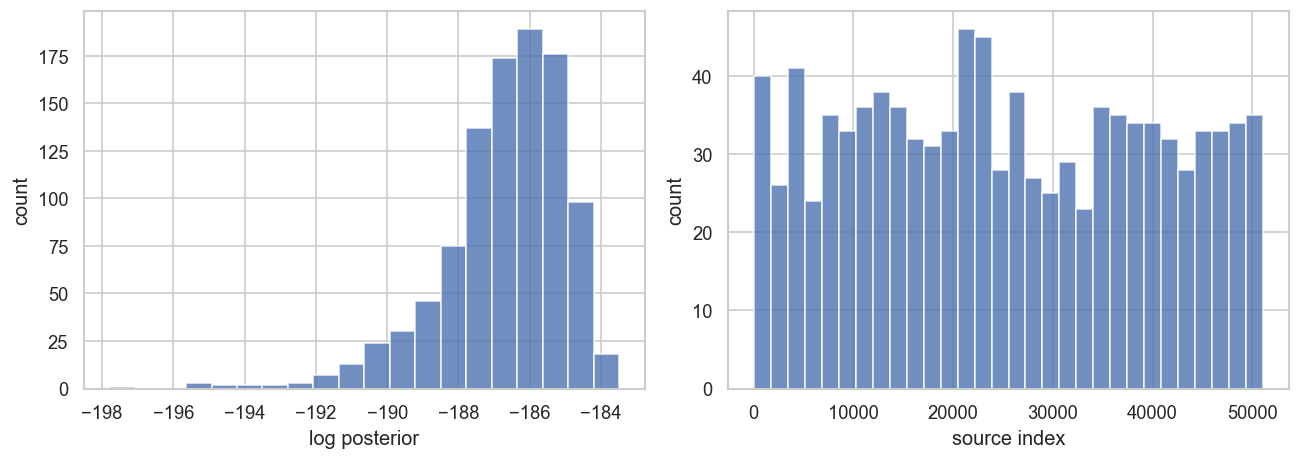

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if "log_prob" in parameter_results_df.columns and parameter_results_df["log_prob"].notna().any():
    axes[0].hist(parameter_results_df["log_prob"].dropna(), bins=20, alpha=0.8)
    axes[0].set_xlabel("log posterior")
elif "best_chi2dN" in parameter_results_df.columns and parameter_results_df["best_chi2dN"].notna().any():
    axes[0].hist(parameter_results_df["best_chi2dN"].dropna(), bins=20, alpha=0.8)
    axes[0].set_xlabel("best chi2/N")
else:
    axes[0].text(0.5, 0.5, "no posterior diagnostic", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_ylabel("count")

pdf_labels = parameter_results_df["pdf_replica_id"].dropna().astype(str) if "pdf_replica_id" in parameter_results_df.columns else pd.Series(dtype=str)
if not pdf_labels.empty:
    if pdf_labels.str.fullmatch(r"-?\d+").all():
        pdf_counts = pdf_labels.astype(int).value_counts().sort_index()
    else:
        pdf_counts = pdf_labels.value_counts().sort_index()
    axes[1].bar(pdf_counts.index.astype(str), pdf_counts.values)
    axes[1].set_xlabel("PDF replica id")
    axes[1].tick_params(axis="x", rotation=90)
elif "source_index" in parameter_results_df.columns and parameter_results_df["source_index"].notna().any():
    axes[1].hist(parameter_results_df["source_index"].dropna(), bins=min(30, max(10, int(np.sqrt(len(parameter_results_df))))), alpha=0.8)
    axes[1].set_xlabel("source index")
else:
    axes[1].text(0.5, 0.5, "no auxiliary index data", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


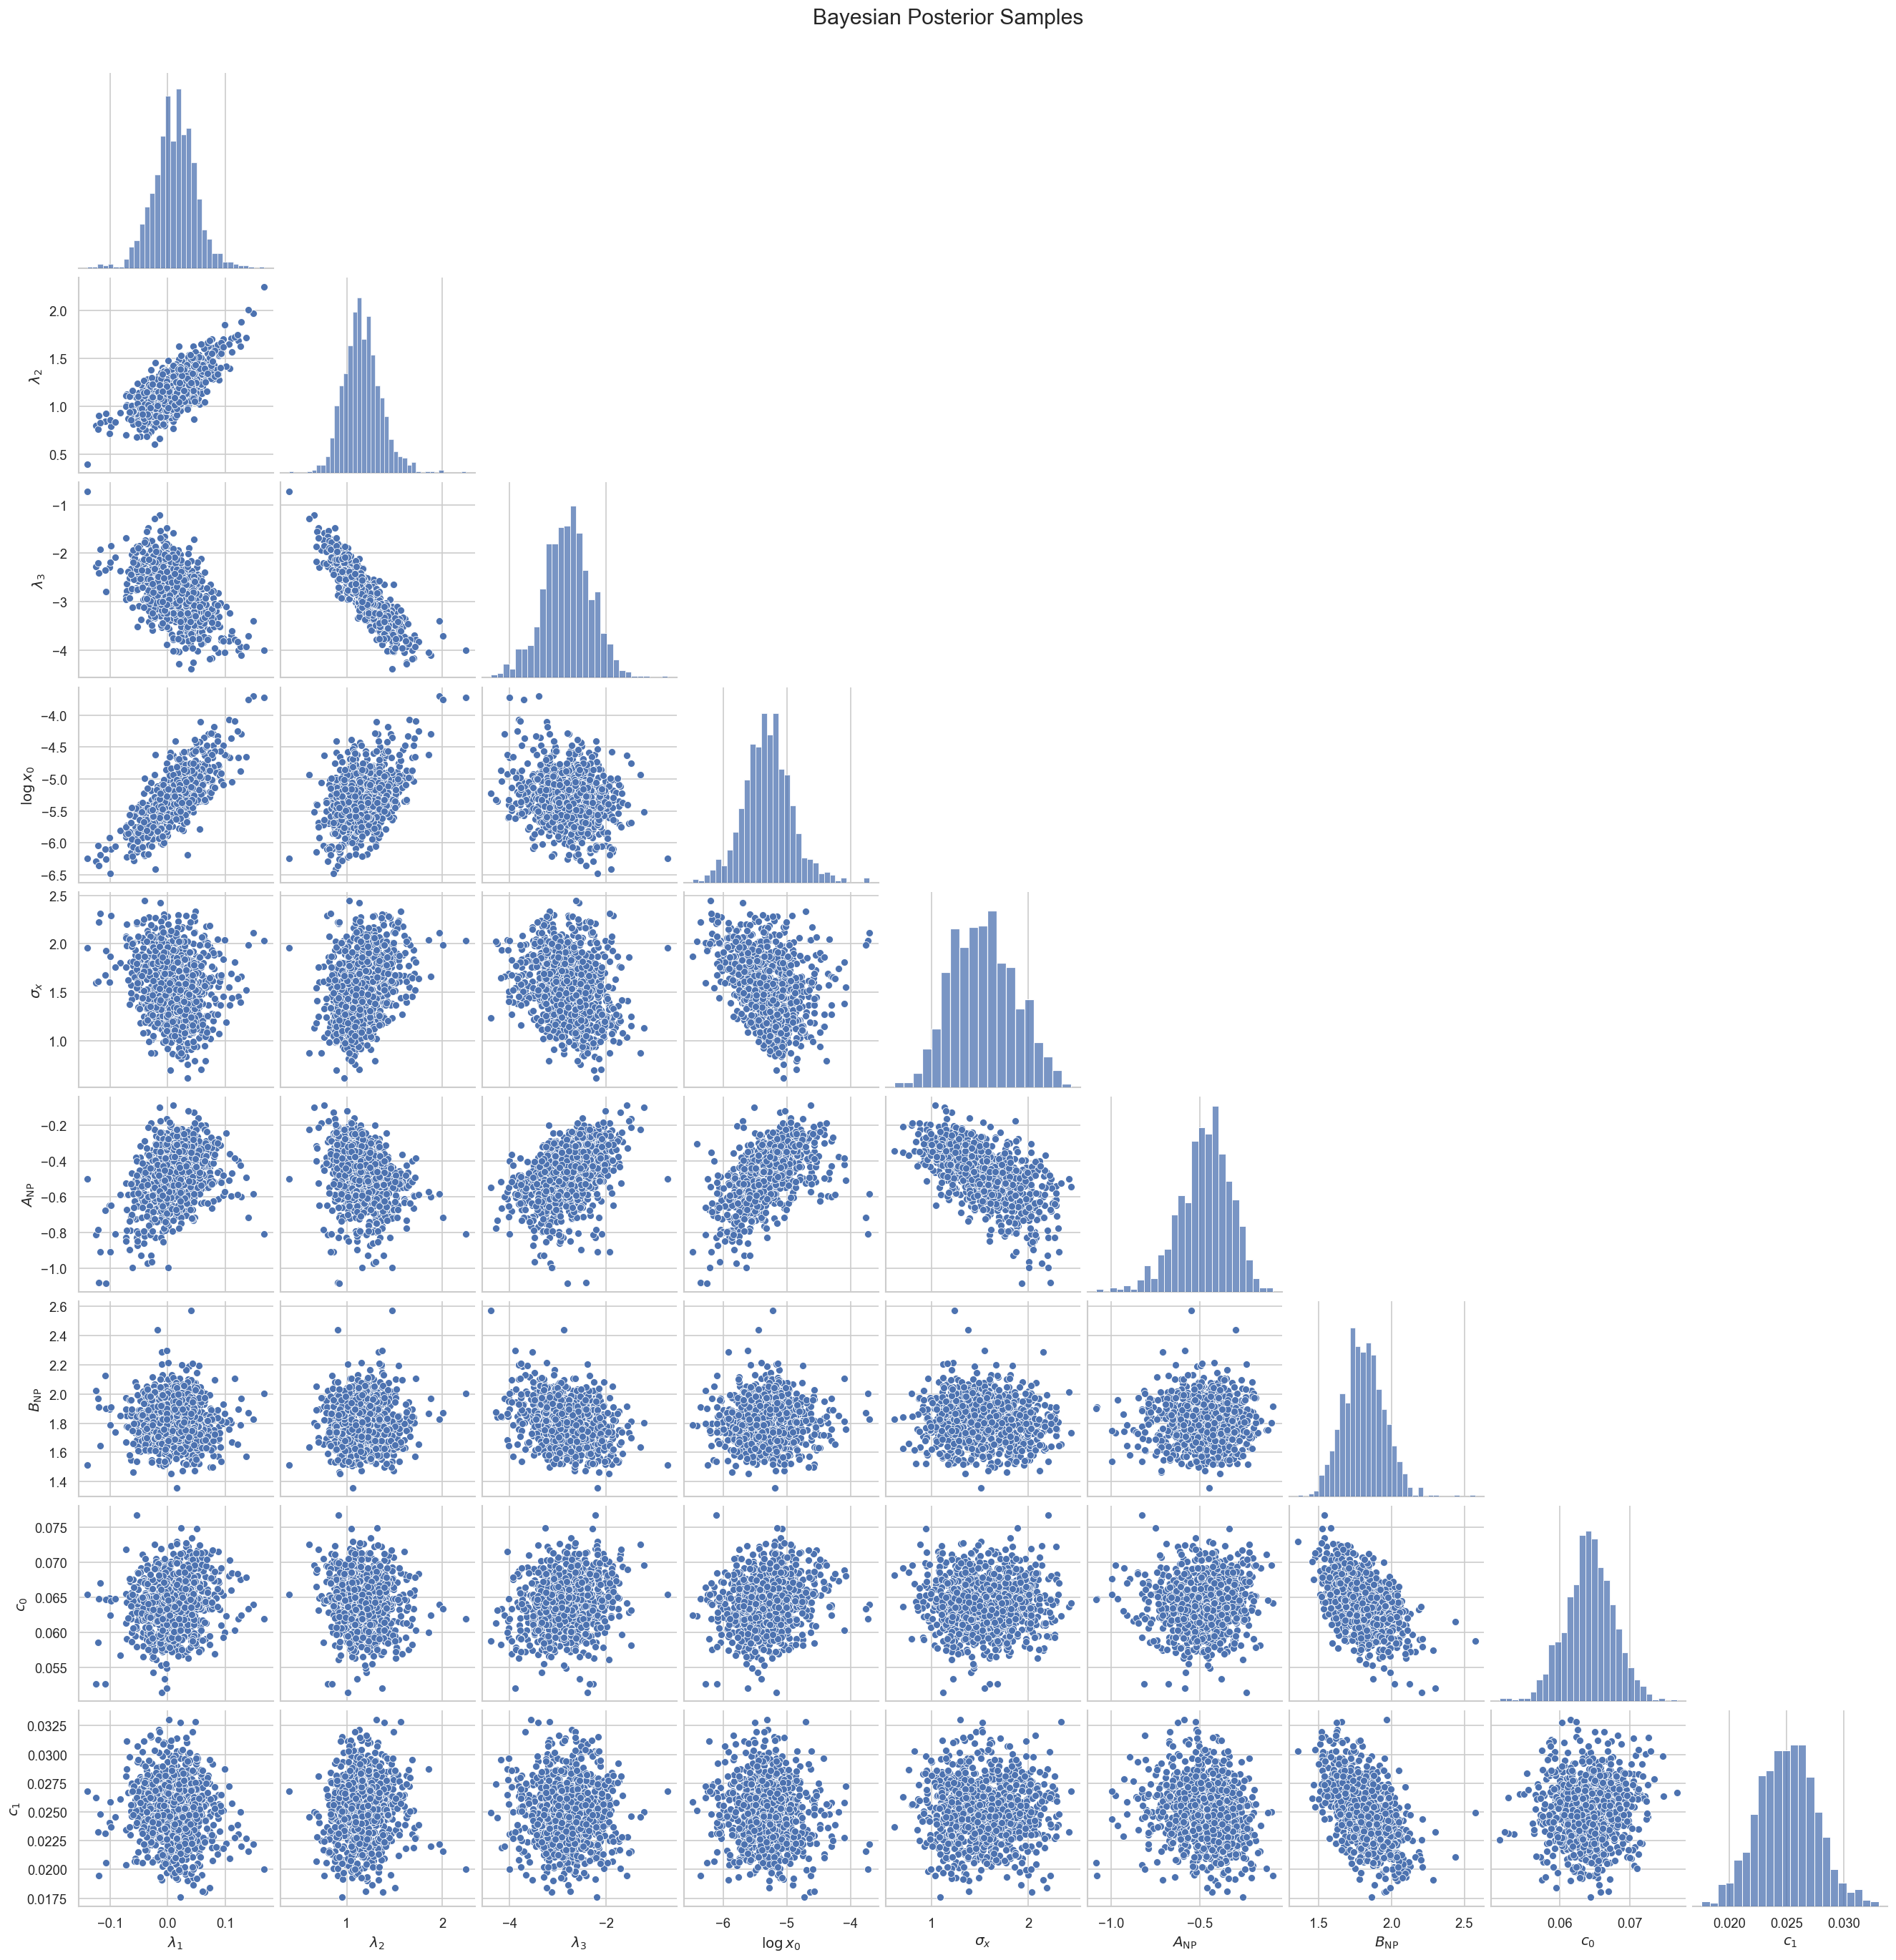

In [7]:
if pairplot_mode == "all":
    pairplot_columns = param_names
else:
    pairplot_columns = [name for i, name in enumerate(param_names) if i not in frozen_set]

plot_df = parameter_results_df[pairplot_columns].copy().rename(columns=latex_param_labels)
g = sns.pairplot(plot_df, corner=True, diag_kind="hist")
g.figure.suptitle("Bayesian Posterior Samples", y=1.02, fontsize=18)
plt.show()

if show_success_failure_overlay:
    if has_explicit_success:
        overlay_df = parameter_results_all_df[pairplot_columns + ["success"]].copy()
        overlay_df["status"] = overlay_df["success"].map({1: "success", 0: "failed"}).fillna("other")
        overlay_df = overlay_df.drop(columns=["success"]).rename(columns=latex_param_labels)
        palette = {"success": "#2E8B57", "failed": "#C44E52", "other": "#7F7F7F"}
        g = sns.pairplot(
            overlay_df,
            vars=[latex_param_labels[name] for name in pairplot_columns],
            hue="status",
            corner=True,
            diag_kind="hist",
            palette=palette,
            plot_kws={"alpha": 0.7, "s": 28, "edgecolor": "none"},
            diag_kws={"alpha": 0.45, "common_norm": False},
        )
        g.figure.suptitle("Success vs Failed Samples", y=1.02, fontsize=18)
        plt.show()
    else:
        print("Skipping success/failure overlay: no explicit success column in Bayesian CSV.")


,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$x_0$,$\sigma_x$,$A_{\rm NP}$,$B_{\rm NP}$,$c_{0}$,$c_{1}$
$\lambda_{1}$,1.000,0.724,-0.518,0.769,-0.182,0.366,-0.046,0.167,-0.088
$\lambda_{2}$,0.724,1.000,-0.882,0.411,0.322,-0.294,0.059,-0.139,0.075
$\lambda_{3}$,-0.518,-0.882,1.000,-0.182,-0.258,0.427,-0.301,0.203,-0.022
$x_0$,0.769,0.411,-0.182,1.000,-0.313,0.538,-0.022,0.185,-0.086
$\sigma_x$,-0.182,0.322,-0.258,-0.313,1.000,-0.610,-0.057,-0.011,-0.005
$A_{\rm NP}$,0.366,-0.294,0.427,0.538,-0.610,1.000,0.036,0.076,-0.145
$B_{\rm NP}$,-0.046,0.059,-0.301,-0.022,-0.057,0.036,1.000,-0.510,-0.533
$c_{0}$,0.167,-0.139,0.203,0.185,-0.011,0.076,-0.510,1.000,0.079
$c_{1}$,-0.088,0.075,-0.022,-0.086,-0.005,-0.145,-0.533,0.079,1.000


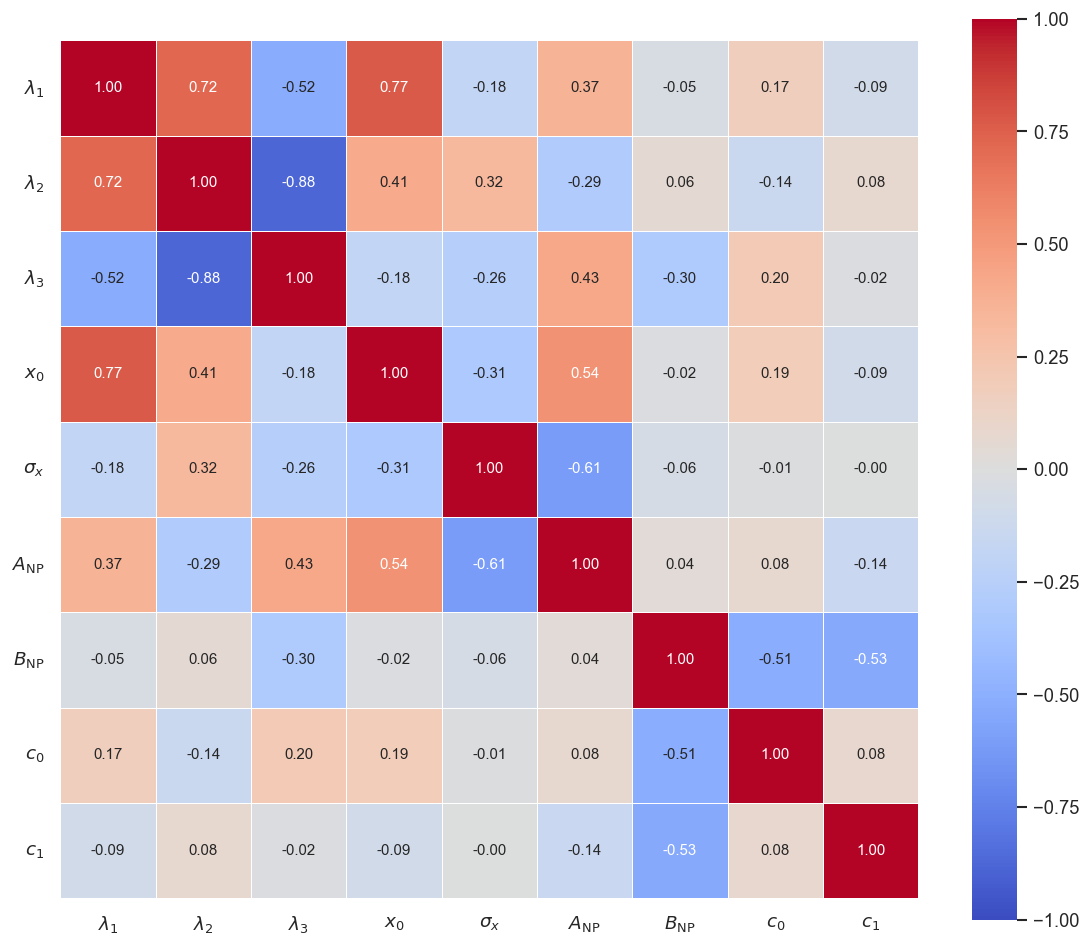

,param_a,param_b,corr,abs_corr
8,$\lambda_{2}$,$\lambda_{3}$,-0.882269,0.882269
2,$\lambda_{1}$,$x_0$,0.768528,0.768528
0,$\lambda_{1}$,$\lambda_{2}$,0.723899,0.723899
26,$\sigma_x$,$A_{\rm NP}$,-0.610291,0.610291
22,$x_0$,$A_{\rm NP}$,0.537980,0.537980
34,$B_{\rm NP}$,$c_{1}$,-0.533119,0.533119
1,$\lambda_{1}$,$\lambda_{3}$,-0.518418,0.518418
33,$B_{\rm NP}$,$c_{0}$,-0.509656,0.509656
17,$\lambda_{3}$,$A_{\rm NP}$,0.427178,0.427178
9,$\lambda_{2}$,$x_0$,0.411138,0.411138


,quantity,value
0,n_parameters,9.000000
1,max_abs_corr_offdiag,0.882269
2,median_abs_corr_offdiag,0.183893
3,min_eigenvalue,0.003134
4,condition_number,892.035527


In [8]:
if len(pairplot_columns) < 2:
    print("Need at least two parameters to analyze correlations.")
else:
    corr_df = parameter_results_df[pairplot_columns].corr()
    corr_plot_labels = dict(latex_param_labels)
    corr_plot_labels["logx0"] = r"$x_0$"
    corr_df.index = [corr_plot_labels[name] for name in corr_df.index]
    corr_df.columns = [corr_plot_labels[name] for name in corr_df.columns]
    display(corr_df.round(3))

    corr_annot = corr_df.apply(lambda col: col.map(lambda value: rf"${value:.2f}$"))

    fig_w = max(7, 0.8 * len(corr_df.columns) + 2.5)
    fig_h = max(6, 0.8 * len(corr_df.columns) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        corr_df,
        annot=corr_annot,
        fmt="",
        annot_kws={"size": 9},
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.9},
        ax=ax,
    )
    ax.tick_params(axis="x", labelrotation=0, labelsize=11)
    ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    plt.tight_layout()
    if export_correlation_pdf:
        correlation_plot_pdf_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(correlation_plot_pdf_path, bbox_inches="tight")
    plt.show()

    upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    corr_pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "param_a", "level_1": "param_b"})
    )
    corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
    corr_pairs = corr_pairs.sort_values(["abs_corr", "param_a", "param_b"], ascending=[False, True, True])
    display(corr_pairs.head(15))

    eigvals = np.linalg.eigvalsh(corr_df.to_numpy())
    corr_summary = pd.DataFrame(
        {
            "quantity": [
                "n_parameters",
                "max_abs_corr_offdiag",
                "median_abs_corr_offdiag",
                "min_eigenvalue",
                "condition_number",
            ],
            "value": [
                len(corr_df.columns),
                corr_pairs["abs_corr"].max() if not corr_pairs.empty else np.nan,
                corr_pairs["abs_corr"].median() if not corr_pairs.empty else np.nan,
                eigvals.min(),
                eigvals.max() / eigvals.min() if eigvals.min() > 0 else np.inf,
            ],
        }
    )
    display(corr_summary)
